In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sklearn
#!pip install prophet
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
#!pip install xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

C:\Users\rhena\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


# Modelo de Previsão

Nesse notebook, tentaremos treinar modelos em cada CISP para prever a evolução dos casos de roubo a coletivo nos próximos anos a partir de nossa série temporal. Inicialmetne, tentaremos utilizar os modelos:
- Prophet
- XGBoost
- Arima

E comparar seus desempenhos.

## carregamento e definições

In [5]:
with open("../datasets/df_treino.pkl","rb") as file:
    df = pickle.load(file)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6027 entries, 17389 to 37491
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   cisp               6027 non-null   int64         
 1   mes                6027 non-null   int64         
 2   ano                6027 non-null   int64         
 3   mes_ano            6027 non-null   datetime64[ns]
 4   furto_coletivo     6027 non-null   float64       
 5   roubo_em_coletivo  6027 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 329.6 KB


Como avaliamos na análise exploratória que roubo e furtos são duas variáveis totalmente separadas, utilizaremos dois datasets e treinaremos em paralelo modelos para ambos os crimes:

In [20]:
df_furtos = df.groupby("cisp")["roubo_em_coletivo"].agg("sum").sort_values().reset_index()
#df_roubos_red = df_roubos[df_roubos["roubo_em_coletivo"]>df_roubos["roubo_em_coletivo"].median()]
#df_roubos_red = df[ df["cisp"].isin(df_roubos["cisp"])]

In [19]:
df_furtos = df.groupby("cisp")["furto_coletivo"].agg("sum").sort_values().reset_index()
#df_furtos_red = df_furtos[df_furtos["furto_coletivo"]>df_furtos["furto_coletivo"].median()]
#df_furtos_red = df[ df["cisp"].isin(df_furtos_red["cisp"])]

## Baseline

Nossa baseline para comparar os modelos será

## Modelo Prophet

Iniciaremos utilizando o modelo Prophet. É um modelo bastante simples de utilizar, e teremos resultados iniciais rápidos e uma boa baseline. Iniciamos treinando o modelo para prever furtos na cisp 1::

16:37:13 - cmdstanpy - INFO - Chain [1] start processing
16:37:13 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\rhena\AppData\Roaming\Python\Python314\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


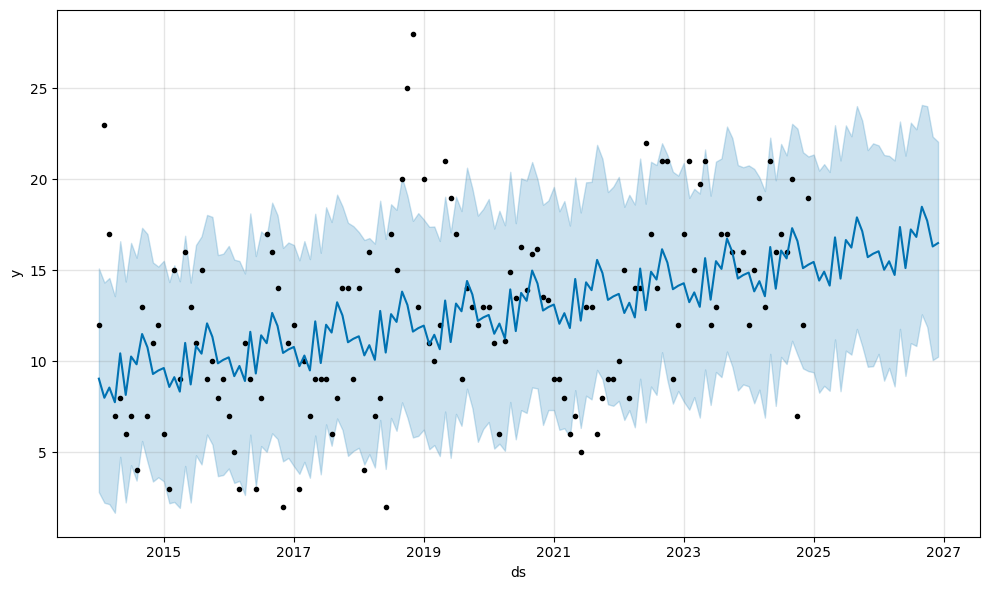

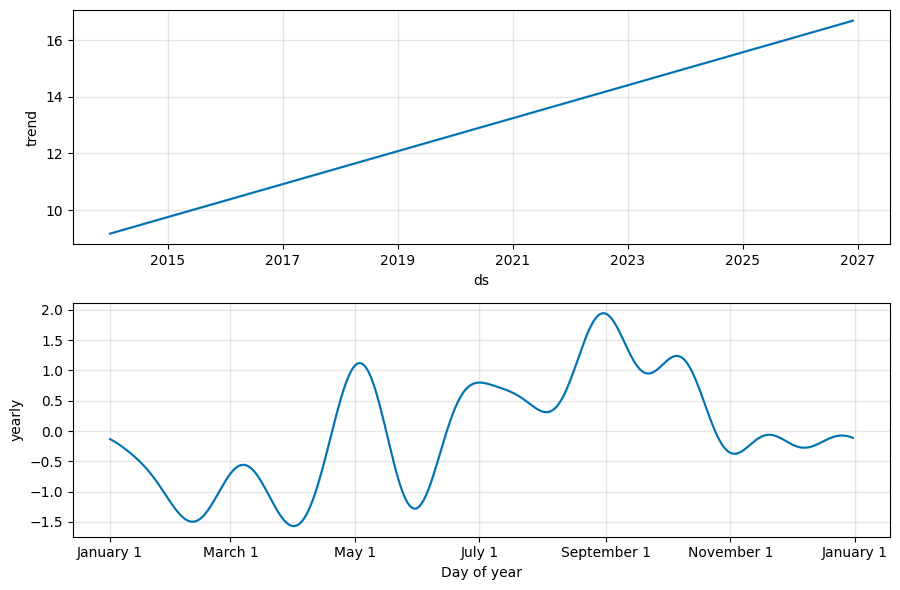

In [34]:
df_pro = df[ np.logical_and(df["cisp"] == 1, df["ano"]<=2024) ][['mes_ano', 'furto_coletivo']]
df_pro.columns = ['ds', 'y']
model = Prophet(yearly_seasonality=True, interval_width=0.8)
model.fit(df_pro)
future = model.make_future_dataframe(periods=24, freq='M')
forecast = model.predict(future)
fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)

Interessante. A trend parece bem clara, porém a sazonalidade parece um pouco confusa. Os intervalos de confiaça para apenas 80% são enormes, o que levanta dúvidas sobre o quão bem o modelo vai performar. Mas talvez seja uma questão de hiperparâmetros ou um ano ruim. Melhor treinar e testar o modelo pra valer. Vamos treinar o modelo em cada CISP, e o prophet já dá a função pra fazer cross-validação bem fácil. Fazendo isso posso avaliar legal a performance do modelo.

In [47]:
len(df[["cisp","furto_coletivo"]].sort_values(by="furto_coletivo")["cisp"].unique())

41

In [48]:
resultados_cv = []
mapes_cv = []
cisps = df[["cisp","furto_coletivo"]].sort_values(by="furto_coletivo")["cisp"].unique()

for cisp in cisps:
    df_pro = df[np.logical_and(df["ano"]<2025, df["cisp"]== cisp)][['mes_ano', 'furto_coletivo']]
    df_pro.columns = ['ds', 'y']
    df_pro['floor'] = 0
    df_pro['cap'] = df_pro['y'].max() * 2
    m = Prophet(
        yearly_seasonality=True,
        growth='logistic',
        interval_width=0.8,
        changepoint_prior_scale=0.1,
        seasonality_prior_scale = 10,
    )
    m.fit(df_pro)
    df_cv = cross_validation(
        m,
        initial='1825 days',   # ~5 anos
        period='365 days',    # validação anual
        horizon='365 days'    # prever 1 ano
    )
    df_p = performance_metrics(df_cv)
    mae_cv = df_p['mae'].mean()
    mape = mae_cv / df[np.logical_and(df["ano"]<2025, df["cisp"]== cisp)]["furto_coletivo"].mean()
    resultados_cv.append(mae_cv)
    mapes_cv.append(mape)
#media = df_furtos_red['furto_coletivo'].mean()
#mae = np.mean(resultados_cv)
print("MAE CV por CISP:", resultados_cv)
print(np.mean(resultados_cv))
print(np.mean(mapes_cv))
#print("Erro relativo:", mae / media)
#print("MAE médio CV:", mae)

16:53:50 - cmdstanpy - INFO - Chain [1] start processing
16:53:50 - cmdstanpy - INFO - Chain [1] done processing
  0%|                                                                                                                        | 0/5 [00:00<?, ?it/s]16:53:51 - cmdstanpy - INFO - Chain [1] start processing
16:53:51 - cmdstanpy - INFO - Chain [1] done processing
 20%|██████████████████████▍                                                                                         | 1/5 [00:00<00:01,  2.29it/s]16:53:51 - cmdstanpy - INFO - Chain [1] start processing
16:53:51 - cmdstanpy - INFO - Chain [1] done processing
 40%|████████████████████████████████████████████▊                                                                   | 2/5 [00:00<00:01,  2.07it/s]16:53:52 - cmdstanpy - INFO - Chain [1] start processing
16:53:52 - cmdstanpy - INFO - Chain [1] done processing
 60%|███████████████████████████████████████████████████████████████████▏                                  

MAE CV por CISP: [np.float64(0.8695912497892404), np.float64(1.1254228204747192), np.float64(3.9233318912412134), np.float64(2.0528829709614005), np.float64(1.9896054476511198), np.float64(4.004697661842276), np.float64(1.844592143744243), np.float64(5.030993855973445), np.float64(4.141671033735191), np.float64(5.949079687317037), np.float64(1.9638567669648588), np.float64(4.587399249220864), np.float64(3.21195374600294), np.float64(3.050670528236249), np.float64(2.685990158656689), np.float64(6.706466807100258), np.float64(3.129973190714118), np.float64(3.3009296146223535), np.float64(5.678672824162739), np.float64(4.00221981465028), np.float64(4.815089099162521), np.float64(3.2260571884707088), np.float64(3.1226387468441383), np.float64(4.571713239058884), np.float64(3.628800207485899), np.float64(5.278253170803715), np.float64(9.535777437013103), np.float64(3.493368791369198), np.float64(4.2341876821958815), np.float64(4.35909419928543), np.float64(4.671757335387382), np.float64(6.0

O prophet teve MAPE de 0.39. Isso indica uma acurácia de cerca de 60% em média. 

## Usando XGBoost

O prophet nos deu resultados legais para previsão, porém podemos tentar melhorar! Vamos tentar usar agora o XGBoost. É um modelo baseado em árvore, preparado para dados tabulares, e por isso vamos inicialmente precisar criar features para que ele possa operar em séries temporais.

### Features
o primeiro passo é criar um dataframe tabular pra passar pro algoritmo, pois ele não é feito para trabalhar com tempo. Criar colunas:

- mes
- ano
- n_furtos(t-1)
- n_furtos(t-3)
- n_furtos(t-12)
- media_furtos_3_meses
- media_furtos_ano
- var_furtos_3meses
- var_furtos_1ano
- furtos(t-1) - furtos(t-12)
- furtos(t-1) - furtos(t-13)
- sin, cos (mes)

E assim fazer o modelo "entender" a sazonalidade, taxa de variação e etc. Vamos criar o dataset, treinar e ver no que dá.

In [42]:
df_furtos_red

,cisp,risp,mes,ano,mes_ano,furto_coletivo,roubo_em_coletivo
17389,1,1,1,2014,2014-01-01,12,5
17390,4,1,1,2014,2014-01-01,42,19
17391,5,1,1,2014,2014-01-01,21,6
17392,6,1,1,2014,2014-01-01,7,10
17394,9,1,1,2014,2014-01-01,20,4
...,...,...,...,...,...,...,...
37482,35,2,3,2026,2026-03-01,11,2
37483,36,2,3,2026,2026-03-01,8,0
37488,41,2,3,2026,2026-03-01,14,3
37489,42,2,3,2026,2026-03-01,10,3


In [49]:
df_xg = df.copy()
df_xg['furtos_t_1'] = df_xg['furto_coletivo'].shift(1)
df_xg['furtos_t_2'] = df_xg['furto_coletivo'].shift(2)
df_xg['furtos_t_3'] = df_xg['furto_coletivo'].shift(3)
df_xg['media_3m'] = df_xg['furto_coletivo'].shift(1).rolling(3).mean()
df_xg['media_12m'] = df_xg['furto_coletivo'].shift(1).rolling(12).mean()
df_xg['var_3m'] = df_xg['furto_coletivo'].shift(1).rolling(3).var()
df_xg['var_12m'] = df_xg['furto_coletivo'].shift(1).rolling(12).var()
df_xg['diff_1_2'] = df_xg['furtos_t_1'] - df_xg['furtos_t_2']
df_xg['furtos_t_12'] = df_xg['furto_coletivo'].shift(12)
df_xg['furtos_t_13'] = df_xg['furto_coletivo'].shift(13)
#df_xg['diff_12_13'] = df_xg['furtos_t_12'] - df_xg['furtos_t_13']
#colunas pra ensinar q meses sao ciclicos 
df_xg['mes_sin'] = np.sin(2 * np.pi * df_xg['mes'] / 12)
df_xg['mes_cos'] = np.cos(2 * np.pi * df_xg['mes'] / 12)

df_xg['is_pandemic'] = np.where(
    (df_xg['ano'] == 2020),
    1,
    0
)
df_xg = df_xg.dropna().reset_index(drop=True)
df_xg

,cisp,mes,ano,mes_ano,furto_coletivo,roubo_em_coletivo,furtos_t_1,furtos_t_2,furtos_t_3,media_3m,media_12m,var_3m,var_12m,diff_1_2,furtos_t_12,furtos_t_13,mes_sin,mes_cos,is_pandemic
0,17,1,2014,2014-01-01,28.0,43.0,26.0,13.0,31.265246,23.421749,21.628756,88.390335,223.972801,13.0,42.0,12.0,0.5,8.660254e-01,0
1,18,1,2014,2014-01-01,13.0,8.0,28.0,26.0,13.000000,22.333333,20.462089,66.333333,188.452059,2.0,21.0,42.0,0.5,8.660254e-01,0
2,19,1,2014,2014-01-01,14.0,2.0,13.0,28.0,26.000000,22.333333,19.795423,66.333333,193.002976,-15.0,7.0,21.0,0.5,8.660254e-01,0
3,20,1,2014,2014-01-01,9.0,2.0,14.0,13.0,28.000000,18.333333,20.378756,70.333333,180.801226,1.0,0.0,7.0,0.5,8.660254e-01,0
4,21,1,2014,2014-01-01,21.0,48.0,9.0,14.0,13.000000,12.000000,21.128756,7.000000,154.204171,-5.0,20.0,0.0,0.5,8.660254e-01,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6009,40,3,2026,2026-03-01,4.0,6.0,7.0,10.0,4.000000,7.000000,12.416667,9.000000,118.810606,-3.0,9.0,12.0,1.0,6.123234e-17,0
6010,41,3,2026,2026-03-01,14.0,3.0,4.0,7.0,10.000000,7.000000,12.000000,9.000000,124.000000,-3.0,34.0,9.0,1.0,6.123234e-17,0
6011,42,3,2026,2026-03-01,10.0,3.0,14.0,4.0,7.000000,8.333333,10.333333,26.333333,77.333333,10.0,13.0,34.0,1.0,6.123234e-17,0
6012,43,3,2026,2026-03-01,2.0,0.0,10.0,14.0,4.000000,9.333333,10.083333,25.333333,76.628788,-4.0,4.0,13.0,1.0,6.123234e-17,0


beleza, tenho o dataset funcionando. agora preciso treinar o modelo de fato

In [142]:
target = 'furto_coletivo'

features = [
    'mes', 'ano',
    'furtos_t_1', 'furtos_t_2', 'furtos_t_3','furtos_t_12', 	
    'media_3m', 'media_12m',
    'var_3m', 'var_12m',
    'diff_1_2', 
    'is_pandemic', "mes_sin","mes_cos"
]
xg_cisp = df_xg[df_xg["cisp"]==17]
X = xg_cisp[features]
y = xg_cisp[target]

In [143]:
train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]
X_train

,mes,ano,furtos_t_1,furtos_t_2,furtos_t_3,furtos_t_12,media_3m,media_12m,var_3m,var_12m,diff_1_2,is_pandemic,mes_sin,mes_cos
28,2,2014,41.0,11.0,25.0,34.0,25.666667,27.833333,225.333333,187.060606,30.0,0,8.660254e-01,5.000000e-01
58,3,2014,40.0,15.0,28.0,28.0,27.666667,26.750000,156.333333,153.295455,25.0,0,1.000000e+00,6.123234e-17
88,4,2014,33.0,12.0,17.0,14.0,20.666667,21.916667,120.333333,163.537879,21.0,0,8.660254e-01,-5.000000e-01
118,5,2014,42.0,14.0,28.0,16.0,28.000000,24.416667,196.000000,140.992424,28.0,0,5.000000e-01,-8.660254e-01
148,6,2014,16.0,9.0,19.0,11.0,14.666667,19.750000,26.333333,114.386364,7.0,0,1.224647e-16,-1.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3358,5,2023,55.0,17.0,18.0,5.0,30.000000,20.083333,469.000000,182.628788,38.0,0,5.000000e-01,-8.660254e-01
3388,6,2023,58.0,16.0,10.0,11.0,28.000000,18.500000,684.000000,209.181818,42.0,0,1.224647e-16,-1.000000e+00
3418,7,2023,43.0,11.0,7.0,9.0,20.333333,18.916667,389.333333,245.356061,32.0,0,-5.000000e-01,-8.660254e-01
3448,8,2023,57.0,17.0,13.0,16.0,29.000000,23.583333,592.000000,239.356061,40.0,0,-8.660254e-01,-5.000000e-01


In [146]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
maes = []
cisps = df_furtos_red[["cisp","furto_coletivo"]].sort_values(by="furto_coletivo")["cisp"].unique()
target = 'furto_coletivo'
features = [
    'mes', 'ano',
    'furtos_t_1', 'furtos_t_2', 'furtos_t_3','furtos_t_12', 	
    'media_3m', 'media_12m',
    'var_3m', 'var_12m',
    'diff_1_2', 'mes_sin',"mes_cos",
    'is_pandemic',
]

mae_cisps = []
for cisp in cisps:
    print(cisp)
    xg_cisp = df_xg[df_xg["cisp"]==cisp]
    X = xg_cisp[features]
    y = xg_cisp[target]
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
        model = XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            random_state=42
        )
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        mae = mean_absolute_error(y_val, pred)
        maes.append(mae)
    mae_cisps.append(np.mean(maes))
print(mae_cisps)
media = df_pro['y'].mean()
print(np.mean(mae_cisps))
media = df_furtos_red['furto_coletivo'].mean()
print(np.mean(mae_cisps)/df_furtos_red['furto_coletivo'].mean())

42
5
59
22
28
33
14
4
23
18
25
19
20
27
13
15
35
36
9
10
1
34
6
41
12
32
17
29
21
16
[np.float64(6.393479728698731), np.float64(6.285619020462036), np.float64(5.85954163869222), np.float64(5.687673044204712), np.float64(5.478664083480835), np.float64(5.337629254659017), np.float64(5.2297458103724885), np.float64(5.864957785606384), np.float64(5.631095144483778), np.float64(5.680531220436096), np.float64(5.683697722174904), np.float64(5.709002308050791), np.float64(5.653742207013644), np.float64(5.6515388590948925), np.float64(5.577793022791544), np.float64(5.47631625533104), np.float64(5.626716821333941), np.float64(5.5963596529430815), np.float64(5.654080794986926), np.float64(5.835219051837921), np.float64(5.841898634320214), np.float64(5.7727094541896475), np.float64(5.919015604516734), np.float64(5.8395485063393915), np.float64(5.878466272354126), np.float64(6.003863996725816), np.float64(6.01940374550996), np.float64(6.064308941364288), np.float64(6.1004454300321385), np.float64(6

In [163]:
def prever_proximos_meses(model, df_cisp, target, n_meses=12):
    df_forecast = df_cisp.copy()
    
    for _ in range(n_meses):
        ultima_linha = df_forecast.iloc[-1]
        proximo_mes_data = ultima_linha['mes_ano'] + pd.DateOffset(months=1)
        nova_linha = {
            'mes_ano': proximo_mes_data,
            'mes': proximo_mes_data.month,
            "mes_cos" : np.cos(2 * np.pi * proximo_mes_data.month / 12),
            "mes_sin" : np.sin(2 * np.pi * proximo_mes_data.month / 12),
            'ano': proximo_mes_data.year,
            'is_pandemic': 0 # Esperamos que sim, né? kkk
        }
        nova_linha['furtos_t_1'] = df_forecast[target].iloc[-1]
        nova_linha['furtos_t_2'] = df_forecast[target].iloc[-2]
        nova_linha['furtos_t_3'] = df_forecast[target].iloc[-3]
        nova_linha['furtos_t_12'] = df_forecast[target].iloc[-12]
        ultimos_3 = df_forecast[target].tail(3)
        ultimos_12 = df_forecast[target].tail(12)
        nova_linha['media_3m'] = ultimos_3.mean()
        nova_linha['media_12m'] = ultimos_12.mean()
        nova_linha['var_3m'] = ultimos_3.var()
        nova_linha['var_12m'] = ultimos_12.var()
        nova_linha['diff_1_2'] = nova_linha['furtos_t_1'] - nova_linha['furtos_t_2']
        #nova_linha['diff_12_13'] = nova_linha['furtos_t_12'] - df_forecast[target].iloc[-13]
        X_novo = pd.DataFrame([nova_linha])[features]
        y_pred = model.predict(X_novo)[0]
        y_pred = max(0, y_pred)
        nova_linha[target] = y_pred
        df_forecast = pd.concat([df_forecast, pd.DataFrame([nova_linha])], ignore_index=True)
        
    return df_forecast

In [164]:
xg_cisp = df_xg[df_xg["cisp"]==32]
xg_cisp = xg_cisp[xg_cisp["ano"] <2025]
X = xg_cisp[features]
y = xg_cisp[target]
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
    )
model.fit(X,y)
forecast = prever_proximos_meses(model, xg_cisp,target, n_meses=12) 
ff = forecast[forecast["ano"]>=2025]["furto_coletivo"]


In [165]:
tttt = df_xg[df_xg["cisp"]==32]
arrT=tttt[tttt["ano"]==2025]["furto_coletivo"]
np.abs(np.array(arrT)-np.array(ff)).mean()/arrT.mean()


np.float64(0.3077887075918692)

In [166]:
model.feature_names_in_

array(['mes', 'ano', 'furtos_t_1', 'furtos_t_2', 'furtos_t_3',
       'furtos_t_12', 'media_3m', 'media_12m', 'var_3m', 'var_12m',
       'diff_1_2', 'mes_sin', 'mes_cos', 'is_pandemic'], dtype='<U11')

In [167]:
model.feature_importances_

array([0.02013128, 0.14935201, 0.06359318, 0.05181029, 0.0302106 ,
       0.24473566, 0.07091933, 0.12585971, 0.06613816, 0.03003203,
       0.0224719 , 0.02347011, 0.04896743, 0.05230838], dtype=float32)

<Axes: >

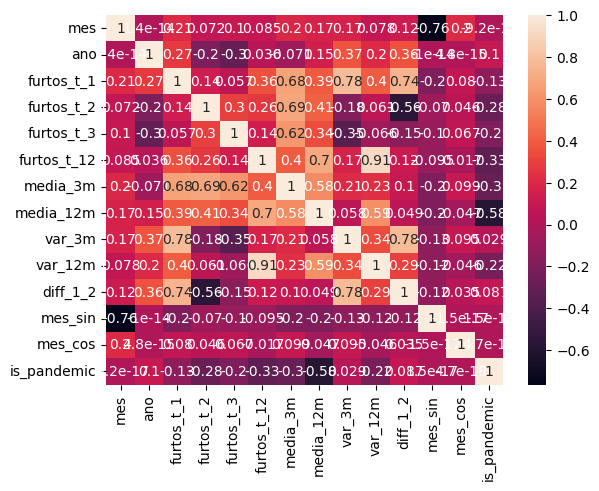

In [168]:
sns.heatmap(xg_cisp[features].corr(),annot=True)

In [169]:
forecast[:24]

,cisp,risp,mes,ano,mes_ano,furto_coletivo,roubo_em_coletivo,furtos_t_1,furtos_t_2,furtos_t_3,media_3m,media_12m,var_3m,var_12m,diff_1_2,furtos_t_12,furtos_t_13,mes_sin,mes_cos,is_pandemic
0,32.0,2.0,1,2014,2014-01-01,21.0,31.0,14.0,12.0,18.0,14.666667,15.750000,9.333333,38.931818,2.0,26.0,13.0,5.000000e-01,8.660254e-01,0
1,32.0,2.0,2,2014,2014-02-01,18.0,24.0,16.0,11.0,11.0,12.666667,18.833333,8.333333,96.333333,5.0,41.0,11.0,8.660254e-01,5.000000e-01,0
2,32.0,2.0,3,2014,2014-03-01,23.0,10.0,16.0,12.0,14.0,14.000000,18.166667,4.000000,116.151515,4.0,40.0,15.0,1.000000e+00,6.123234e-17,0
3,32.0,2.0,4,2014,2014-04-01,34.0,11.0,26.0,13.0,7.0,15.333333,18.666667,94.333333,77.878788,13.0,33.0,12.0,8.660254e-01,-5.000000e-01,0
4,32.0,2.0,5,2014,2014-05-01,21.0,6.0,13.0,9.0,12.0,11.333333,15.750000,4.333333,104.750000,4.0,42.0,14.0,5.000000e-01,-8.660254e-01,0
5,32.0,2.0,6,2014,2014-06-01,17.0,8.0,12.0,8.0,7.0,9.000000,13.250000,7.000000,22.022727,4.0,16.0,9.0,1.224647e-16,-1.000000e+00,0
6,32.0,2.0,7,2014,2014-07-01,30.0,18.0,17.0,6.0,8.0,10.333333,16.333333,34.333333,67.151515,11.0,35.0,10.0,-5.000000e-01,-8.660254e-01,0
7,32.0,2.0,8,2014,2014-08-01,30.0,10.0,8.0,9.0,6.0,7.666667,17.416667,2.333333,237.174242,-1.0,60.0,11.0,-8.660254e-01,-5.000000e-01,0
8,32.0,2.0,9,2014,2014-09-01,22.0,30.0,21.0,17.0,18.0,18.666667,17.083333,4.333333,57.537879,4.0,35.0,27.0,-1.000000e+00,-1.836970e-16,0
9,32.0,2.0,10,2014,2014-10-01,18.0,77.0,21.0,15.0,12.0,16.000000,18.250000,21.000000,97.659091,6.0,38.0,11.0,-8.660254e-01,5.000000e-01,0
